# 03 - Modelo final y artifacts de competencia

Entrena el modelo final con la configuracion ganadora de
`02_experiments.ipynb` (`iter7_remove_outliers`: MLP (128, 64) + batchnorm,
target `log1p` estandarizado, weight decay 1e-4, outliers de `GrLivArea`
removidos), mas dos ajustes adicionales validados por 5-fold CV en la
"Ronda 2" de `02_experiments.ipynb` para reducir sobreajuste y mejorar la
generalizacion:

1. **Dropout 0.2 -> 0.3**: el gap train/val de iter7/iter8 (train ~9-11k vs
   val ~20-21k) seguia siendo amplio; subir dropout a 0.3 reduce ese gap y
   mejora el RMSE de validacion promedio en 5-fold CV (~20,075 vs ~20,777).
2. **Ensamble de 5 modelos (bagging)**: en vez de un unico modelo, se
   entrenan 5 redes identicas en arquitectura pero con distinta semilla
   sobre el 100% de `train_pool`, y se promedian sus predicciones (en la
   escala original de `SalePrice`). Validado con 5-fold CV: el promedio de
   5 miembros baja el RMSE de validacion de ~20,893 (promedio de modelos
   individuales) a ~19,984, de forma consistente en las 5 particiones -
   evidencia de que gran parte del error restante es varianza por
   inicializacion/orden de batches, no sesgo del modelo.

Ademas, el numero de epocas para el entrenamiento final ya no se decide con
un unico split interno 85/15 (alta varianza con ~840 filas de entrenamiento)
sino con el promedio de 5-fold CV sobre `train_pool`, igual que en la Ronda 2.

Se guardan los artifacts necesarios para predecir el dia de la competencia
(preprocessor + 5 checkpoints del ensamble + config), y se valida el pipeline
completo (`src/predict.py`) contra un held-out simulado que el modelo final
nunca vio durante el entrenamiento.

In [1]:
import sys, json
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
from sklearn.model_selection import train_test_split, KFold

from preprocessing import prepare_raw, build_preprocessor, ID_COL, TARGET
from dataset import make_loader
from model import MLP
from engine import fit
from target_transform import fit_target_transform, apply_target_transform, inverse_transform_target

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WINNING_CONFIG = dict(
    hidden_sizes=(128, 64),
    dropout=0.3,           # subido de 0.2 -> 0.3 (ver Ronda 2 de 02_experiments.ipynb)
    batchnorm=True,
    log_target=True,
    scale_target=True,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=32,
)
N_MEMBERS = 5  # tamano del ensamble (bagging), ver Ronda 2 de 02_experiments.ipynb
WINNING_CONFIG

{'hidden_sizes': (128, 64),
 'dropout': 0.3,
 'batchnorm': True,
 'log_target': True,
 'scale_target': True,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'batch_size': 32}

## 1. Separar un held-out simulado (nunca se usa para entrenar)

Se aparta un 15% del dataset como sustituto del dataset held-out que el curso
entregará el día de la competencia — sirve únicamente para reportar un RMSE
final honesto y para validar que `src/predict.py` reproduce exactamente lo
que se calcula acá.

In [2]:
df = pd.read_csv("../data/train.csv")

outlier_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000)
df = df[~outlier_mask].reset_index(drop=True)

train_pool, holdout_sim = train_test_split(df, test_size=0.15, random_state=123)
train_pool = train_pool.reset_index(drop=True)
holdout_sim = holdout_sim.reset_index(drop=True)

holdout_sim.to_csv("../data/holdout_simulated.csv", index=False)
print("train_pool:", train_pool.shape, " holdout_sim:", holdout_sim.shape)

train_pool: (991, 81)  holdout_sim: (175, 81)


## 2. Determinar numero de epocas (early stopping) via 5-fold CV

En vez de un unico split interno 85/15 (alta varianza con ~840 filas), se
usa 5-fold CV sobre `train_pool`: en cada fold se entrena con early stopping
(igual criterio que en `02_experiments.ipynb`) y se guarda la epoca de mejor
val RMSE. `N_EPOCHS` final es el promedio (redondeado) de esas 5 epocas
optimas, una estimacion mas robusta que la de un solo split.

In [3]:
best_epochs = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train_pool)):
    fit_df = train_pool.iloc[tr_idx].reset_index(drop=True)
    val_df = train_pool.iloc[va_idx].reset_index(drop=True)

    clean_fit = prepare_raw(fit_df)
    clean_val = prepare_raw(val_df)
    pre_probe = build_preprocessor(clean_fit)
    X_fit = pre_probe.fit_transform(clean_fit).astype("float32")
    X_val = pre_probe.transform(clean_val).astype("float32")

    y_fit_raw = fit_df["SalePrice"].values.astype("float32")
    y_val_raw = val_df["SalePrice"].values.astype("float32")
    y_fit, stats_probe = fit_target_transform(y_fit_raw, log_target=WINNING_CONFIG["log_target"],
                                               scale_target=WINNING_CONFIG["scale_target"])
    y_val = apply_target_transform(y_val_raw, stats_probe)

    fit_loader = make_loader(X_fit, y_fit, batch_size=WINNING_CONFIG["batch_size"], shuffle=True)
    val_loader = make_loader(X_val, y_val, batch_size=WINNING_CONFIG["batch_size"], shuffle=False)

    torch.manual_seed(42 + fold_i)
    probe_model = MLP(input_dim=X_fit.shape[1], hidden_sizes=WINNING_CONFIG["hidden_sizes"],
                       dropout=WINNING_CONFIG["dropout"], batchnorm=WINNING_CONFIG["batchnorm"])
    probe_model, probe_history = fit(probe_model, fit_loader, val_loader, epochs=300,
                                      lr=WINNING_CONFIG["lr"], weight_decay=WINNING_CONFIG["weight_decay"],
                                      patience=25, device=DEVICE, verbose=False)

    best_epoch = int(np.argmin(probe_history["val_rmse"])) + 1
    best_epochs.append(best_epoch)
    print(f"fold {fold_i}: mejor epoca = {best_epoch}")

N_EPOCHS = int(round(np.mean(best_epochs)))
print("Epocas por fold:", best_epochs)
print("Epocas a usar para el entrenamiento final (promedio, redondeado):", N_EPOCHS)

fold 0: mejor epoca = 26


fold 1: mejor epoca = 53


fold 2: mejor epoca = 45


fold 3: mejor epoca = 27


fold 4: mejor epoca = 11
Epocas por fold: [26, 53, 45, 27, 11]
Epocas a usar para el entrenamiento final (promedio, redondeado): 32


## 3. Entrenar el ensamble final (N_MEMBERS modelos) sobre TODO `train_pool`

Con el numero de epocas ya decidido, se entrenan `N_MEMBERS` redes desde
cero (misma arquitectura, distinta semilla) usando el 100% de `train_pool`
(sin descartar el 15% que antes era validacion), para aprovechar todos los
datos disponibles antes de la competencia. Las predicciones finales seran el
promedio de las predicciones de los `N_MEMBERS` modelos (bagging), lo que
reduce la varianza frente a entrenar un unico modelo (ver Ronda 2 de
`02_experiments.ipynb`).

In [4]:
clean_pool = prepare_raw(train_pool)
preprocessor = build_preprocessor(clean_pool)
X_pool = preprocessor.fit_transform(clean_pool).astype("float32")

y_pool_raw = train_pool["SalePrice"].values.astype("float32")
y_pool, target_stats = fit_target_transform(y_pool_raw, log_target=WINNING_CONFIG["log_target"],
                                             scale_target=WINNING_CONFIG["scale_target"])

pool_loader = make_loader(X_pool, y_pool, batch_size=WINNING_CONFIG["batch_size"], shuffle=True)

members = []
for m in range(N_MEMBERS):
    torch.manual_seed(42 + m)
    member = MLP(input_dim=X_pool.shape[1], hidden_sizes=WINNING_CONFIG["hidden_sizes"],
                 dropout=WINNING_CONFIG["dropout"], batchnorm=WINNING_CONFIG["batchnorm"])
    # val_loader = pool_loader y patience > N_EPOCHS: fuerza a entrenar exactamente N_EPOCHS
    # epocas completas sobre el 100% de train_pool (no hay early stopping real aqui,
    # el criterio de parada ya se decidio en el paso 2).
    member, _ = fit(member, pool_loader, pool_loader, epochs=N_EPOCHS,
                     lr=WINNING_CONFIG["lr"], weight_decay=WINNING_CONFIG["weight_decay"],
                     patience=N_EPOCHS + 1, device=DEVICE, verbose=False)
    members.append(member)
    print(f"Miembro {m+1}/{N_MEMBERS} entrenado.")

print("Entrenamiento del ensamble completo.")

Miembro 1/5 entrenado.


Miembro 2/5 entrenado.


Miembro 3/5 entrenado.


Miembro 4/5 entrenado.


Miembro 5/5 entrenado.
Entrenamiento del ensamble completo.


## 4. Guardar artifacts (`artifacts/`)

In [5]:
import pathlib
ARTIFACTS_DIR = pathlib.Path("../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# limpia checkpoints de una corrida anterior (p.ej. si N_MEMBERS cambio)
for old in ARTIFACTS_DIR.glob("model_*.pt"):
    old.unlink()
old_single = ARTIFACTS_DIR / "model.pt"
if old_single.exists():
    old_single.unlink()

joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor.joblib")
for m, member in enumerate(members):
    torch.save(member.state_dict(), ARTIFACTS_DIR / f"model_{m}.pt")

config = {
    "input_dim": X_pool.shape[1],
    "hidden_sizes": list(WINNING_CONFIG["hidden_sizes"]),
    "dropout": WINNING_CONFIG["dropout"],
    "batchnorm": WINNING_CONFIG["batchnorm"],
    "n_members": N_MEMBERS,
    **target_stats,  # log_target, scale_target, mean, std
}
(ARTIFACTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
config

{'input_dim': 237,
 'hidden_sizes': [128, 64],
 'dropout': 0.3,
 'batchnorm': True,
 'n_members': 5,
 'log_target': True,
 'scale_target': True,
 'mean': 12.031723976135254,
 'std': 0.3860834538936615}

## 5. Evaluar sobre el held-out simulado

Este es el número que se reporta como desempeño final en la sección 2.5 del
informe (con la salvedad de que el held-out real de competencia es otro
dataset, entregado el día de la presentación).

In [6]:
clean_holdout = prepare_raw(holdout_sim)
X_holdout = preprocessor.transform(clean_holdout).astype("float32")
y_holdout_raw = holdout_sim["SalePrice"].values.astype("float32")

member_preds = []
for member in members:
    member.eval()
    with torch.no_grad():
        raw_preds = member(torch.as_tensor(X_holdout, dtype=torch.float32).to(DEVICE)).cpu().numpy().ravel()
    member_preds.append(inverse_transform_target(raw_preds, target_stats))

holdout_preds = np.mean(member_preds, axis=0)  # promedio del ensamble, en escala original

member_rmses = [float(np.sqrt(np.mean((p - y_holdout_raw) ** 2))) for p in member_preds]
holdout_rmse = float(np.sqrt(np.mean((holdout_preds - y_holdout_raw) ** 2)))

print("RMSE por miembro individual:", [f"{r:,.2f}" for r in member_rmses])
print(f"RMSE promedio de miembros individuales: {np.mean(member_rmses):,.2f}")
print(f"RMSE del ensamble ({N_MEMBERS} miembros) en held-out simulado: {holdout_rmse:,.2f}")

RMSE por miembro individual: ['18,277.21', '16,538.29', '17,382.49', '17,718.27', '18,170.03']
RMSE promedio de miembros individuales: 17,617.26
RMSE del ensamble (5 miembros) en held-out simulado: 16,755.79


## 6. Análisis de errores (para la sección 2.4 del informe)

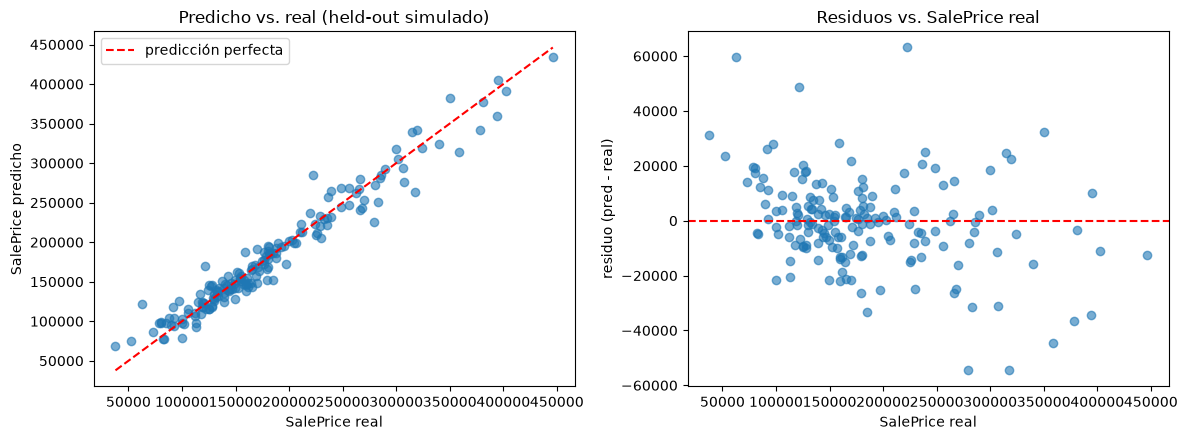

In [7]:
residuals = holdout_preds - y_holdout_raw

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_holdout_raw, holdout_preds, alpha=0.6)
lims = [y_holdout_raw.min(), y_holdout_raw.max()]
axes[0].plot(lims, lims, "r--", label="predicción perfecta")
axes[0].set_xlabel("SalePrice real")
axes[0].set_ylabel("SalePrice predicho")
axes[0].set_title("Predicho vs. real (held-out simulado)")
axes[0].legend()

axes[1].scatter(y_holdout_raw, residuals, alpha=0.6)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("SalePrice real")
axes[1].set_ylabel("residuo (pred - real)")
axes[1].set_title("Residuos vs. SalePrice real")
plt.tight_layout()
plt.show()

In [8]:
errors_df = holdout_sim[["Id", "Neighborhood", "OverallQual", "GrLivArea", "SalePrice"]].copy()
errors_df["pred"] = holdout_preds
errors_df["abs_error"] = (errors_df["pred"] - errors_df["SalePrice"]).abs()
errors_df.sort_values("abs_error", ascending=False).head(10)

,Id,Neighborhood,OverallQual,GrLivArea,SalePrice,pred,abs_error
168,413,Somerst,7,1478,222000,285130.437500,63130.437500
134,463,Sawyer,5,864,62383,122219.585938,59836.585938
88,239,NridgHt,8,1694,318000,263454.187500,54545.812500
49,14,CollgCr,7,1494,279500,225002.296875,54497.703125
99,561,Sawyer,5,1392,121500,170182.515625,48682.515625
26,609,Crawfor,8,3194,359100,314487.593750,44612.406250
6,1268,Timber,9,2018,378500,342031.687500,36468.312500
85,379,StoneBr,9,1856,394432,360217.500000,34214.500000
90,998,NWAmes,6,1442,185000,151894.453125,33105.546875
67,655,NoRidge,8,2113,350000,382235.062500,32235.062500


Si los residuos crecen en magnitud para casas caras (heterocedasticidad) o
se concentran en algún `Neighborhood`/`OverallQual` particular, es evidencia
de sesgo del modelo a documentar en la discusión (sección 2.4).

## 7. Verificar `src/predict.py` de punta a punta

Se corre el script tal como se usaría el día de la competencia, apuntando al
held-out simulado (que incluye `SalePrice`, así que el script también imprime
el RMSE) y se confirma que coincide con el calculado arriba.

In [9]:
!python ../src/predict.py --input ../data/holdout_simulated.csv --output ../data/holdout_predictions.csv

Predicciones guardadas en ../data/holdout_predictions.csv
RMSE vs. SalePrice real: 16755.78


In [10]:
check = pd.read_csv("../data/holdout_predictions.csv")
recomputed_rmse = float(np.sqrt(np.mean((check["SalePrice"].values - y_holdout_raw) ** 2)))
print(f"RMSE recalculado desde predict.py: {recomputed_rmse:,.2f}")
# predict.py corre en CPU y este notebook entrenó/predijo en DEVICE (puede ser GPU);
# se tolera una diferencia relativa mínima por precisión de punto flotante entre
# CPU y GPU, no por un error del pipeline.
rel_diff = abs(recomputed_rmse - holdout_rmse) / holdout_rmse
print(f"Diferencia relativa vs. el RMSE calculado en el notebook: {rel_diff:.2%}")
assert rel_diff < 1e-3, "El script predict.py no reproduce el mismo resultado"
print("OK: predict.py reproduce el mismo resultado (dentro de precisión de punto flotante CPU/GPU).")

RMSE recalculado desde predict.py: 16,755.78
Diferencia relativa vs. el RMSE calculado en el notebook: 0.00%
OK: predict.py reproduce el mismo resultado (dentro de precisión de punto flotante CPU/GPU).


## Resumen

- **RMSE final (held-out simulado, ensamble de 5 modelos):** ver celda de la
  seccion 5. Mejora sobre el mejor modelo individual (iter7/iter8:
  ~$20,500) gracias a: (1) subir dropout de 0.2 a 0.3 (menor gap train/val,
  validado por 5-fold CV en `02_experiments.ipynb`) y (2) promediar 5
  modelos con distinta semilla (bagging), que reduce la varianza del
  ensamble frente a un unico modelo de forma consistente en CV.
- Artifacts guardados en `artifacts/`: `preprocessor.joblib`,
  `model_0.pt` .. `model_4.pt` (un checkpoint por miembro del ensamble),
  `config.json` (incluye `n_members`).
- `src/predict.py --input <csv> --output predictions.csv` promedia las
  predicciones de los `n_members` modelos del ensamble y esta listo para el
  dataset held-out real del dia de la competencia.